# TCN Punch Classification Training (Baseline)

Train a Temporal Convolutional Network as a baseline comparison against ST-GCN.

**Input:** (T=40, 9 joints, 3 XYZ) flattened to (T=40, 27) — joint relationships not explicitly modeled
**Output:** Class probability distribution over 5 classes (jab, cross, hook, uppercut, no_punch)
**Architecture:** TCN with dilated 1D convolutions
**Data:** unified `data/clips/with_hardware/` + `data/metadata/with_hardware/labels.csv` (shared with the regression pipeline)
**Validation:** two protocols, mirroring `notebooks/regression/02_train_tcn.ipynb`:
- Within-subject — stratified 80/20 random split per session
- Cross-subject CV — leave-one-`person_id`-out

This notebook is structurally identical to `train_stgcn.ipynb` — only the model architecture differs.

In [1]:
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Configuration

Same hyperparameters as ST-GCN for fair comparison.

In [2]:
PROJECT_ROOT = Path("../../")

METADATA_DIR = PROJECT_ROOT / "data" / "metadata" / "with_hardware"
CLIPS_DIR = PROJECT_ROOT / "data" / "clips" / "with_hardware"
LABELS_CSV = METADATA_DIR / "labels.csv"
SUBJECTS_CSV = METADATA_DIR / "subjects.csv"
MODELS_DIR = PROJECT_ROOT / "models" / "tcn"
LOGS_DIR = PROJECT_ROOT / "logs" / "tensorboard"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

# Data parameters
T = 40
N_JOINTS = 9
N_CHANNELS = 3  # XYZ
N_FEATURES = N_JOINTS * N_CHANNELS  # 27 flattened features per frame
N_CLASSES = 5
CLASS_TO_IDX = {"cross": 0, "hook": 1, "jab": 2, "uppercut": 3, "no_punch": 4}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# Training hyperparameters (matching ST-GCN for fair comparison)
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 80
WEIGHT_DECAY = 1e-4

# Evaluation protocols (mirrors notebooks/regression/02_train_tcn.ipynb)
RUN_WITHIN_SUBJECT_SPLIT = True   # stratified 80/20 random split per session
RUN_CROSS_SUBJECT_CV = True       # leave-one-person_id-out

# Optional quick debug split — not one of the two reported protocols
RUN_DEBUG_SINGLE_SPLIT = False
DEBUG_TEST_SUBJECT = "subject04"

# Tensorboard run name
RUN_NAME = f"tcn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

print(f"Run name: {RUN_NAME}")
print(f"Logs:     {LOGS_DIR / RUN_NAME}")
print(f"Models:   {MODELS_DIR}")

Run name: tcn_20260714_140355
Logs:     ../../logs/tensorboard/tcn_20260714_140355
Models:   ../../models/tcn


## Dataset Class

Same as ST-GCN dataset, but reshapes output to (T, N_FEATURES) for TCN input.

In [3]:
class PunchDatasetTCN(Dataset):
    """PyTorch Dataset for TCN — flattens joint dimension into features."""
    
    def __init__(self, annotations_df: pd.DataFrame, clips_dir: Path, T: int, augment: bool = True):
        self.df = annotations_df.reset_index(drop=True)
        self.clips_dir = clips_dir
        self.T = T
        self.augment = augment
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_path = self.clips_dir / row["class"] / f"{row['clip_id']}.npy"
        clip = np.load(clip_path).astype(np.float32)  # (frames, 9, 3)
        
        clip = self._pad_or_truncate(clip)  # (T, 9, 3)
        
        # Flatten joints + xyz into features per frame: (T, 27)
        # Then transpose to (C=27, T) for Conv1d
        clip = clip.reshape(self.T, -1).transpose(1, 0)
        
        tensor = torch.from_numpy(clip)
        label = CLASS_TO_IDX[row["class"]]
        
        return tensor, label
    
    def _pad_or_truncate(self, clip: np.ndarray) -> np.ndarray:
        clip_len = clip.shape[0]
        if clip_len >= self.T:
            return clip[:self.T]
        
        if self.augment:
            offset = random.randint(0, self.T - clip_len)
            pre_pad = np.repeat(clip[:1], offset, axis=0)
            post_pad = np.repeat(clip[-1:], self.T - offset - clip_len, axis=0)
            return np.concatenate([pre_pad, clip, post_pad], axis=0)
        
        pad_amount = self.T - clip_len
        last_frame = clip[-1:].repeat(pad_amount, axis=0)
        return np.concatenate([clip, last_frame], axis=0)


# Load unified labels (shared with regression, see notebooks/regression/01_preprocessing.ipynb)
labels_df = pd.read_csv(LABELS_CSV)
subjects_meta = pd.read_csv(SUBJECTS_CSV)
labels_df = labels_df.merge(
    subjects_meta[["subject_id", "person_id"]],
    on="subject_id",
)
df_all = labels_df

print(f"Total clips: {len(df_all)}")
print(f"Class distribution:\n{df_all['class'].value_counts()}")
print(f"Persons: {sorted(df_all['person_id'].unique())}")
print(f"Sessions (subject_id): {sorted(df_all['subject_id'].unique())}")

# Quick test
test_ds = PunchDatasetTCN(df_all.head(2), CLIPS_DIR, T=T, augment=False)
sample_tensor, sample_label = test_ds[0]
print(f"\nSample tensor shape: {sample_tensor.shape}  (expected: ({N_FEATURES}, {T}))")
print(f"Sample label: {sample_label} ({IDX_TO_CLASS[sample_label]})")

Total clips: 3300
Class distribution:
class
cross       745
jab         745
hook        742
uppercut    740
no_punch    328
Name: count, dtype: int64
Persons: ['person01', 'person02', 'person03', 'person04', 'person05', 'person07', 'person08', 'person09', 'person10', 'person11']
Sessions (subject_id): ['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14']

Sample tensor shape: torch.Size([27, 40])  (expected: (27, 40))
Sample label: 0 (cross)


## TCN Model

Dilated 1D convolutions across the time axis. Joints are flattened into channels — the model has no explicit knowledge of joint connectivity, which is the key distinction from ST-GCN.

**Architecture:**
- Multiple TCN blocks with exponentially increasing dilation
- Each block: dilated Conv1d → BatchNorm → ReLU → Dropout
- Residual connections
- Final: global average pooling → classification head

In [4]:
class TCNBlock(nn.Module):
    """Single TCN block: dilated Conv1d + BN + ReLU + Dropout + residual."""
    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int = 5, dilation: int = 1, dropout: float = 0.3):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        
        # Residual projection if channels change
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        res = self.residual(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        x = self.relu(x + res)
        x = self.dropout(x)
        return x


class TCN(nn.Module):
    """Temporal Convolutional Network for punch classification."""
    def __init__(self, in_channels: int = N_FEATURES, n_classes: int = N_CLASSES,
                 channels: list = [32, 64, 128], kernel_size: int = 5, dropout: float = 0.3):
        super().__init__()
        
        self.data_bn = nn.BatchNorm1d(in_channels)
        
        layers = []
        prev_channels = in_channels
        for i, ch in enumerate(channels):
            dilation = 2 ** i  # 1, 2, 4
            layers.append(TCNBlock(prev_channels, ch, kernel_size, dilation, dropout))
            prev_channels = ch
        
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(prev_channels, n_classes)
    
    def forward(self, x):
        # x: (B, C, T)
        x = self.data_bn(x)
        x = self.tcn(x)
        x = x.mean(dim=2)  # Global avg pool over time → (B, C')
        x = self.fc(x)
        return x


# Sanity check
model = TCN().to(DEVICE)
sample_input = torch.randn(2, N_FEATURES, T).to(DEVICE)
sample_output = model(sample_input)
print(f"Model output shape: {sample_output.shape}  (expected: (2, {N_CLASSES}))")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([2, 5])  (expected: (2, 5))
Total parameters: 176,411


## Training Loop

Same as ST-GCN training loop, just with TCN model.

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += inputs.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += inputs.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(train_df, test_df, run_name, epochs=EPOCHS):
    """Train one TCN model on the given split."""
    
    train_ds = PunchDatasetTCN(train_df, CLIPS_DIR, T=T, augment=True)
    test_ds = PunchDatasetTCN(test_df, CLIPS_DIR, T=T, augment=False)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    print(f"Train: {len(train_ds)} clips | Test: {len(test_ds)} clips")
    
    model = TCN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    writer = SummaryWriter(LOGS_DIR / run_name)
    
    # -1 sentinel (not 0) so the first epoch's checkpoint always gets saved, even if
    # test accuracy happens to be exactly 0.0 on a tiny/early split.
    best_test_acc = -1.0
    best_model_path = MODELS_DIR / f"{run_name}_best.pt"
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion)
        scheduler.step()
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/test", test_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/test", test_acc, epoch)
        writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), best_model_path)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
                  f"Test loss {test_loss:.4f} acc {test_acc:.3f} | "
                  f"Best {best_test_acc:.3f}")
    
    writer.close()
    print(f"\nBest test accuracy: {best_test_acc:.4f}")
    print(f"Best model saved to: {best_model_path}")
    
    return history, best_model_path, best_test_acc

In [6]:
if RUN_DEBUG_SINGLE_SPLIT:
    train_df = df_all[df_all["subject_id"] != DEBUG_TEST_SUBJECT].reset_index(drop=True)
    test_df = df_all[df_all["subject_id"] == DEBUG_TEST_SUBJECT].reset_index(drop=True)

    print(f"Train subjects: {sorted(train_df['subject_id'].unique())}")
    print(f"Test subject:   {DEBUG_TEST_SUBJECT}")
    print()

    history, best_model_path, best_acc = train_model(train_df, test_df, RUN_NAME)
else:
    print("Debug single-split skipped (RUN_DEBUG_SINGLE_SPLIT = False). "
          "See the within-subject and cross-subject CV cells below for the reported protocols.")

Debug single-split skipped (RUN_DEBUG_SINGLE_SPLIT = False). See the within-subject and cross-subject CV cells below for the reported protocols.


## Training Visualizations

In [7]:
if RUN_DEBUG_SINGLE_SPLIT:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    epochs_range = range(1, len(history["train_loss"]) + 1)
    
    axes[0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0].plot(epochs_range, history["test_loss"], label="Test")
    axes[0].set_title("Loss (TCN)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(epochs_range, history["train_acc"], label="Train")
    axes[1].plot(epochs_range, history["test_acc"], label="Test")
    axes[1].set_title("Accuracy (TCN)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Debug single-split skipped — no training curves to show here.")

Debug single-split skipped — no training curves to show here.


## Confusion Matrix

In [8]:
class_names = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]

if RUN_DEBUG_SINGLE_SPLIT:
    model = TCN().to(DEVICE)
    model.load_state_dict(torch.load(best_model_path))

    test_ds = PunchDatasetTCN(test_df, CLIPS_DIR, T=T)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    _, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion)

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(N_CLASSES)))

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"TCN Confusion Matrix — Test Accuracy: {test_acc:.4f}")
    plt.tight_layout()
    plt.show()

    print("\nPer-class accuracy:")
    for i, name in enumerate(class_names):
        class_total = (np.array(all_labels) == i).sum()
        class_correct = ((np.array(all_labels) == i) & (np.array(all_preds) == i)).sum()
        if class_total > 0:
            print(f"  {name}: {class_correct/class_total:.3f}  ({class_correct}/{class_total})")
else:
    print("Debug single-split skipped — no confusion matrix to show here.")

Debug single-split skipped — no confusion matrix to show here.


## Within-Subject Split (Stratified 80/20 Per Session)

Each session in this dataset contains only one punch type, so leave-one-session-out would
make every fold hold out a single class — conflating session reliability with class-level
distribution shift. Instead, stratify an 80/20 split within each session so every session
contributes proportionally to train and test. This mirrors `RUN_WITHIN_SESSION_SPLIT` in
`notebooks/regression/02_train_tcn.ipynb`, so both tasks share an identical within-subject design.

Set `RUN_WITHIN_SUBJECT_SPLIT = True` in the configuration cell to enable.

Train clips: 2646
Test clips:  654

Per-session split:
  subject01: train=173, test=43 (20% in test)
  subject02: train=177, test=44 (20% in test)
  subject03: train=232, test=57 (20% in test)
  subject04: train=263, test=65 (20% in test)
  subject05: train=198, test=49 (20% in test)
  subject06: train=196, test=49 (20% in test)
  subject07: train=210, test=52 (20% in test)
  subject08: train=211, test=52 (20% in test)
  subject10: train=200, test=49 (20% in test)
  subject11: train=195, test=48 (20% in test)
  subject12: train=200, test=49 (20% in test)
  subject13: train=199, test=49 (20% in test)
  subject14: train=192, test=48 (20% in test)

Class distribution:
  Train: {'jab': 610, 'cross': 602, 'hook': 591, 'uppercut': 579, 'no_punch': 264}
  Test:  {'uppercut': 161, 'hook': 151, 'cross': 143, 'jab': 135, 'no_punch': 64}

Train: 2646 clips | Test: 654 clips
Epoch   1/80 | Train loss 0.7653 acc 0.717 | Test loss 0.3811 acc 0.875 | Best 0.875
Epoch   5/80 | Train loss 0.1178 acc 0.

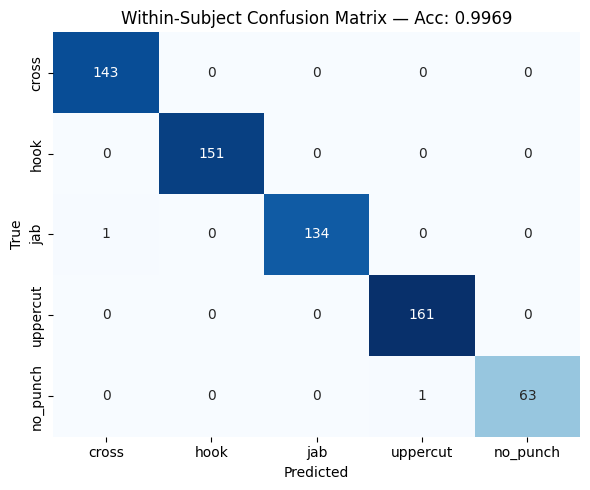


WITHIN-SUBJECT 80/20 SPLIT SUMMARY
  Accuracy: 0.9969
  Saved to: ../../models/tcn/tcn_20260714_140355_within_subject


In [9]:
class_names = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]

if RUN_WITHIN_SUBJECT_SPLIT:
    # Stratified 80/20 random split within each session.
    # Every session contributes proportionally to train and test sets.
    np.random.seed(SEED)
    
    train_indices = []
    test_indices = []
    
    for session in sorted(df_all["subject_id"].unique()):
        session_indices = df_all.index[df_all["subject_id"] == session].tolist()
        np.random.shuffle(session_indices)
        n_test = int(len(session_indices) * 0.2)
        test_indices.extend(session_indices[:n_test])
        train_indices.extend(session_indices[n_test:])
    
    train_df_ws = df_all.loc[train_indices].copy().reset_index(drop=True)
    test_df_ws = df_all.loc[test_indices].copy().reset_index(drop=True)
    
    print(f"Train clips: {len(train_df_ws)}")
    print(f"Test clips:  {len(test_df_ws)}")
    print()
    
    # Verify proportional sampling per session
    print("Per-session split:")
    for session in sorted(df_all["subject_id"].unique()):
        n_train = (train_df_ws["subject_id"] == session).sum()
        n_test = (test_df_ws["subject_id"] == session).sum()
        total = n_train + n_test
        pct_test = 100 * n_test / total if total > 0 else 0
        print(f"  {session}: train={n_train}, test={n_test} ({pct_test:.0f}% in test)")
    print()
    
    # Also verify class balance per split
    print("Class distribution:")
    print(f"  Train: {train_df_ws['class'].value_counts().to_dict()}")
    print(f"  Test:  {test_df_ws['class'].value_counts().to_dict()}")
    print()
    
    ws_run_name = f"{RUN_NAME}_within_subject"
    ws_dir = MODELS_DIR / ws_run_name
    ws_dir.mkdir(parents=True, exist_ok=True)
    
    history_ws, ws_model_path, ws_acc = train_model(
        train_df_ws, test_df_ws, ws_run_name, epochs=EPOCHS
    )
    
    # Confusion matrix on the held-out 20%
    model_ws = TCN().to(DEVICE)
    model_ws.load_state_dict(torch.load(ws_model_path))
    test_loader_ws = DataLoader(
        PunchDatasetTCN(test_df_ws, CLIPS_DIR, T=T, augment=False),
        batch_size=BATCH_SIZE, shuffle=False
    )
    _, ws_test_acc, ws_preds, ws_labels = evaluate(
        model_ws, test_loader_ws, nn.CrossEntropyLoss()
    )
    cm_ws = confusion_matrix(ws_labels, ws_preds, labels=list(range(N_CLASSES)))
    
    # Save artifacts
    np.save(ws_dir / "confusion_matrix.npy", cm_ws)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_ws, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Within-Subject Confusion Matrix — Acc: {ws_test_acc:.4f}")
    plt.tight_layout()
    plt.savefig(ws_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Save metrics summary
    ws_metrics = {
        "protocol": "within_subject_80_20_stratified",
        "accuracy": ws_test_acc,
        "n_train": len(train_df_ws),
        "n_test": len(test_df_ws),
    }
    pd.DataFrame([ws_metrics]).to_csv(ws_dir / "ws_metrics.csv", index=False)
    
    print(f"\n{'=' * 60}")
    print("WITHIN-SUBJECT 80/20 SPLIT SUMMARY")
    print(f"{'=' * 60}")
    print(f"  Accuracy: {ws_test_acc:.4f}")
    print(f"  Saved to: {ws_dir}")
else:
    print("Within-subject 80/20 split skipped (RUN_WITHIN_SUBJECT_SPLIT = False). Set it to True in the configuration cell to enable.")

In [10]:
# --- Verification: within-subject split composition + confusion-matrix sanity check ---
# Unlike the cross-subject matrix (which sums to the FULL dataset), this confusion
# matrix covers only the held-out 20%. Confirms its row totals equal the true test
# class counts, and that train + test reconstruct the full dataset.

assert RUN_WITHIN_SUBJECT_SPLIT, "Run the within-subject split cell above first."

class_order = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]  # matches CM row/col order

train_counts = np.array([(train_df_ws["class"] == c).sum() for c in class_order], dtype=int)
test_counts  = np.array([(test_df_ws["class"]  == c).sum() for c in class_order], dtype=int)
dataset_counts = np.array([(df_all["class"]     == c).sum() for c in class_order], dtype=int)

print("Within-subject 80/20 split — class composition")
print("=" * 68)
print(f"{'class':<10}{'train':>8}{'test':>8}{'total':>8}{'% test':>9}")
print("-" * 68)
for c, tr, te in zip(class_order, train_counts, test_counts):
    tot = tr + te
    pct = 100 * te / tot if tot else 0
    print(f"{c:<10}{tr:>8}{te:>8}{tot:>8}{pct:>8.1f}%")
print("-" * 68)
print(f"{'SUM':<10}{train_counts.sum():>8}{test_counts.sum():>8}{dataset_counts.sum():>8}")

# Assertion 1: train + test == full dataset (no clip lost or duplicated)
assert np.array_equal(train_counts + test_counts, dataset_counts), (
    "train + test class counts do NOT match the dataset."
)
print("\n[OK] train + test == full dataset (nothing lost or duplicated).")

# Assertion 2: confusion-matrix row totals == held-out test class counts
cm_ws_row_sums = cm_ws.sum(axis=1)
print("CM row sums (plotted): ", dict(zip(class_order, cm_ws_row_sums.tolist())))
print("True test counts:      ", dict(zip(class_order, test_counts.tolist())))
assert np.array_equal(cm_ws_row_sums, test_counts), (
    "Within-subject confusion-matrix row totals do NOT match the test class counts."
)
print("[OK] Confusion-matrix row totals match the held-out test class counts exactly.")
print(f"     -> Total clips in matrix: {cm_ws.sum()} (= the held-out 20%, not the full dataset)")

Within-subject 80/20 split — class composition
class        train    test   total   % test
--------------------------------------------------------------------
cross          602     143     745    19.2%
hook           591     151     742    20.4%
jab            610     135     745    18.1%
uppercut       579     161     740    21.8%
no_punch       264      64     328    19.5%
--------------------------------------------------------------------
SUM           2646     654    3300

[OK] train + test == full dataset (nothing lost or duplicated).
CM row sums (plotted):  {'cross': 143, 'hook': 151, 'jab': 135, 'uppercut': 161, 'no_punch': 64}
True test counts:       {'cross': 143, 'hook': 151, 'jab': 135, 'uppercut': 161, 'no_punch': 64}
[OK] Confusion-matrix row totals match the held-out test class counts exactly.
     -> Total clips in matrix: 654 (= the held-out 20%, not the full dataset)


## Cross-Subject CV (Person-Level)

Leave-one-`person_id`-out. For each held-out person, train on all sessions of all other
persons and test on all sessions of the held-out person — measures generalization to
unseen individuals.

Set `RUN_CROSS_SUBJECT_CV = True` in the configuration cell to enable.

Running 10-fold cross-subject (leave-one-person-out) CV across persons: ['person01', 'person02', 'person03', 'person04', 'person05', 'person07', 'person08', 'person09', 'person10', 'person11']

FOLD 1/10 — Test person: person01
  Test sessions: ['subject01', 'subject02', 'subject03']
Train: 2574 clips | Test: 726 clips
Epoch   1/80 | Train loss 0.7867 acc 0.695 | Test loss 0.6324 acc 0.835 | Best 0.835
Epoch   5/80 | Train loss 0.1008 acc 0.969 | Test loss 0.6874 acc 0.857 | Best 0.875
Epoch  10/80 | Train loss 0.1150 acc 0.963 | Test loss 0.5985 acc 0.851 | Best 0.875
Epoch  15/80 | Train loss 0.0548 acc 0.982 | Test loss 0.5178 acc 0.868 | Best 0.909
Epoch  20/80 | Train loss 0.0418 acc 0.986 | Test loss 0.6208 acc 0.862 | Best 0.909
Epoch  25/80 | Train loss 0.0364 acc 0.987 | Test loss 0.5219 acc 0.895 | Best 0.909
Epoch  30/80 | Train loss 0.0205 acc 0.993 | Test loss 0.7447 acc 0.815 | Best 0.909
Epoch  35/80 | Train loss 0.0154 acc 0.996 | Test loss 0.3827 acc 0.924 | Best 0.939

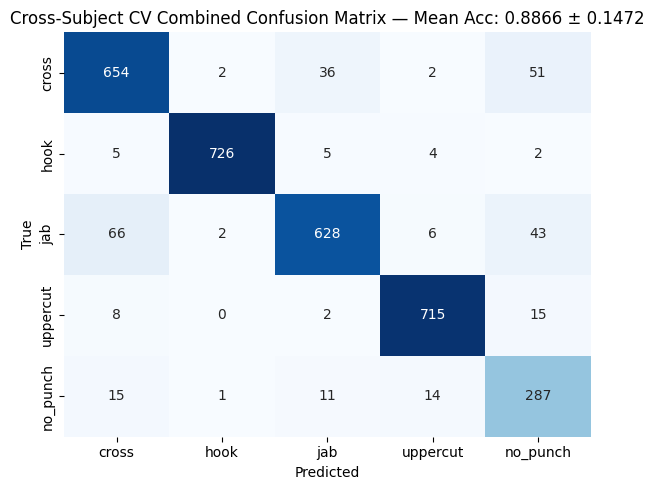


Results saved to: ../../models/tcn/tcn_20260714_140355


In [11]:
if RUN_CROSS_SUBJECT_CV:
    persons = sorted(df_all["person_id"].unique())
    print(f"Running {len(persons)}-fold cross-subject (leave-one-person-out) CV across persons: {persons}\n")
    
    fold_results_cs = []
    cm_combined_cs = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
    
    for fold_idx, test_person in enumerate(persons):
        print("=" * 60)
        print(f"FOLD {fold_idx + 1}/{len(persons)} — Test person: {test_person}")
        print("=" * 60)
        
        train_df_fold = df_all[df_all["person_id"] != test_person].reset_index(drop=True)
        test_df_fold = df_all[df_all["person_id"] == test_person].reset_index(drop=True)
        test_sessions = sorted(test_df_fold["subject_id"].unique())
        print(f"  Test sessions: {test_sessions}")
        
        fold_run_name = f"{RUN_NAME}_cs_fold{fold_idx+1}_{test_person}"
        history_f, model_path_f, best_acc_f = train_model(
            train_df_fold, test_df_fold, fold_run_name, epochs=EPOCHS
        )
        
        m = TCN().to(DEVICE)
        m.load_state_dict(torch.load(model_path_f))
        test_loader_f = DataLoader(
            PunchDatasetTCN(test_df_fold, CLIPS_DIR, T=T),
            batch_size=BATCH_SIZE, shuffle=False
        )
        _, acc_f, preds_f, labels_f = evaluate(m, test_loader_f, nn.CrossEntropyLoss())
        cm_f = confusion_matrix(labels_f, preds_f, labels=list(range(N_CLASSES)))
        cm_combined_cs += cm_f
        
        fold_results_cs.append({
            "fold": fold_idx + 1,
            "test_person": test_person,
            "test_sessions": ",".join(test_sessions),
            "best_acc": best_acc_f,
        })
    
    cs_results_df = pd.DataFrame(fold_results_cs)
    mean_acc_cs = cs_results_df["best_acc"].mean()
    std_acc_cs = cs_results_df["best_acc"].std()
    
    print("\n" + "=" * 60)
    print("CROSS-SUBJECT (PERSON-LEVEL) CV SUMMARY")
    print("=" * 60)
    for r in fold_results_cs:
        print(f"  Fold {r['fold']} ({r['test_person']}): {r['best_acc']:.4f}")
    print(f"\n  Mean: {mean_acc_cs:.4f} ± {std_acc_cs:.4f}")
    
    cs_run_dir = MODELS_DIR / RUN_NAME
    cs_run_dir.mkdir(parents=True, exist_ok=True)
    cs_results_df.to_csv(cs_run_dir / "cv_results_cross_subject.csv", index=False)
    np.save(cs_run_dir / "confusion_matrix_cross_subject.npy", cm_combined_cs)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_combined_cs, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Cross-Subject CV Combined Confusion Matrix — Mean Acc: {mean_acc_cs:.4f} ± {std_acc_cs:.4f}")
    plt.tight_layout()
    plt.savefig(cs_run_dir / "confusion_matrix_cross_subject.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    print(f"\nResults saved to: {cs_run_dir}")
else:
    print("Cross-subject CV skipped (RUN_CROSS_SUBJECT_CV = False). Set it to True in the configuration cell to enable.")

## Verification — Per-Fold Test Counts & Confusion-Matrix Sanity Check

Prints the exact number of each punch type held out in every fold, then asserts two things:

1. **Pooled folds == full dataset** — every clip is a test sample in exactly one fold (leave-one-person-out), so summing folds reconstructs the whole dataset *once*, with no double-counting.
2. **Confusion-matrix row totals == dataset class counts** — proves the numbers in the combined confusion matrix are traceable to the raw data.

The cell raises an `AssertionError` if either check fails, so a clean run is itself the proof.

In [12]:
# --- Verification: per-fold test composition + confusion-matrix sanity check ---
# Proves the cross-subject combined confusion matrix is the sum of each fold's test
# set, with every clip held out exactly once. Ties the plotted numbers back to the
# raw data so they can be shown to be traceable, not hallucinated.

assert RUN_CROSS_SUBJECT_CV, "Run the cross-subject CV cell above first."

persons = sorted(df_all["person_id"].unique())
class_order = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]  # matches CM row/col order
fold_acc = {r["test_person"]: r["best_acc"] for r in fold_results_cs}

print("Per-fold test-set composition (ground-truth punch counts held out each fold)")
print("=" * 92)
header = (f"{'fold':>4}  {'test_person':<12}"
          + "".join(f"{c:>10}" for c in class_order)
          + f"{'total':>8}{'acc':>8}")
print(header)
print("-" * 92)

per_fold_totals = np.zeros(N_CLASSES, dtype=int)
for fold_idx, test_person in enumerate(persons):
    test_df_fold = df_all[df_all["person_id"] == test_person]
    counts = np.array([(test_df_fold["class"] == c).sum() for c in class_order], dtype=int)
    per_fold_totals += counts
    row = (f"{fold_idx + 1:>4}  {test_person:<12}"
           + "".join(f"{n:>10}" for n in counts)
           + f"{counts.sum():>8}{fold_acc[test_person]:>8.4f}")
    print(row)

print("-" * 92)
print(f"{'SUM':>4}  {'(all folds)':<12}"
      + "".join(f"{n:>10}" for n in per_fold_totals)
      + f"{per_fold_totals.sum():>8}")

# Independent reference: full dataset class counts
dataset_counts = np.array([(df_all["class"] == c).sum() for c in class_order], dtype=int)
print("\nFull dataset counts:  ", dict(zip(class_order, dataset_counts.tolist())))
print("Summed across folds:  ", dict(zip(class_order, per_fold_totals.tolist())))

# Assertion 1: pooled folds == full dataset (each clip tested exactly once)
assert np.array_equal(per_fold_totals, dataset_counts), (
    "Pooled fold test counts do NOT match the dataset — a clip was tested "
    "more than once or dropped."
)
print("\n[OK] Every clip is held out exactly once: pooled folds == full dataset.")

# Assertion 2: the plotted confusion matrix row sums == true class counts
cm_row_sums = cm_combined_cs.sum(axis=1)
print("CM row sums (plotted): ", dict(zip(class_order, cm_row_sums.tolist())))
assert np.array_equal(cm_row_sums, dataset_counts), (
    "Confusion-matrix row totals do NOT match the dataset class counts — "
    "the visualization is inconsistent with the data."
)
print("[OK] Confusion-matrix row totals match the dataset class counts exactly.")
print("     -> The combined confusion matrix is traceable to the data, not hallucinated.")
print(f"     -> Total clips in matrix: {cm_combined_cs.sum()} (= full dataset, each clip once)")

Per-fold test-set composition (ground-truth punch counts held out each fold)
fold  test_person      cross      hook       jab  uppercut  no_punch   total     acc
--------------------------------------------------------------------------------------------
   1  person01           140       141       140       140       165     726  0.9394
   2  person02           121       120       120       120        94     575  0.9687
   3  person03            60        60        60        60         5     245  1.0000
   4  person04            60        60        60        60        22     262  0.9962
   5  person05            62        60        62        62        17     263  0.9202
   6  person07            61        60        60        60         8     249  0.8474
   7  person08            60        60        61        60         2     243  0.7819
   8  person09            60        60        61        60         8     249  0.9799
   9  person10            61        61        61        58       

## Summary

In [14]:
print("=" * 60)
print("TCN BASELINE TRAINING SUMMARY")
print("=" * 60)
print(f"Run name:           {RUN_NAME}")
print(f"Model architecture: TCN ({sum(p.numel() for p in TCN().parameters()):,} params)")
print(f"Total clips:        {len(df_all)}")
print(f"Classes:            {sorted(df_all['class'].unique())}")
print(f"Sessions:           {sorted(df_all['subject_id'].unique())}")
print(f"Persons:            {sorted(df_all['person_id'].unique())}")
print(f"T window:           {T}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Learning rate:      {LEARNING_RATE}")
print(f"Epochs:             {EPOCHS}")

if RUN_DEBUG_SINGLE_SPLIT:
    print(f"\nDebug single-split (test={DEBUG_TEST_SUBJECT}): {best_acc:.4f}")
if RUN_WITHIN_SUBJECT_SPLIT:
    print(f"Within-subject 80/20 split:       {ws_test_acc:.4f}")
if RUN_CROSS_SUBJECT_CV:
    print(f"Cross-subject CV ({len(persons)} folds):    {mean_acc_cs:.4f} ± {std_acc_cs:.4f}")
print("=" * 60)

TCN BASELINE TRAINING SUMMARY
Run name:           tcn_20260714_140355
Model architecture: TCN (176,411 params)
Total clips:        3300
Classes:            ['cross', 'hook', 'jab', 'no_punch', 'uppercut']
Sessions:           ['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14']
Persons:            ['person01', 'person02', 'person03', 'person04', 'person05', 'person07', 'person08', 'person09', 'person10', 'person11']
T window:           40
Batch size:         32
Learning rate:      0.001
Epochs:             80
Within-subject 80/20 split:       0.9969
Cross-subject CV (10 folds):    0.8866 ± 0.1472
